In [58]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")
import plotly.express as px

In [59]:
df = pd.read_csv('global_placement.csv')
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,104124.367838
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,80586.838313
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,114444.318097
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,120000.000000
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,120000.000000


#  Basic Dataset Understanding

In [60]:
df.shape

(10000, 13)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
 12  salary                    10000 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB


In [62]:
df.columns

Index(['cgpa', 'backlogs', 'college_tier', 'country',
       'university_ranking_band', 'internship_count', 'aptitude_score',
       'communication_score', 'specialization', 'industry',
       'internship_quality_score', 'placement_status', 'salary'],
      dtype='object')

In [63]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,salary
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436,55442.146458
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975,47995.029325
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000,0.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656,0.000000
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335,63431.317260
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400,100600.617480
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000,120000.000000


In [64]:
numeric_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Total Numeric:", len(numeric_features))
print("Total Categorical:", len(categorical_features))

Total Numeric: 7
Total Categorical: 6


In [65]:
df['country'].value_counts().count()

np.int64(5)

In [66]:
df['country'].unique()

array(['Canada', 'UK', 'USA', 'Germany', 'India'], dtype=object)

#  Academic Performance Analysis

In [67]:
df['cgpa'].mean()

np.float64(6.998289620233497)

In [68]:
df['cgpa'].max()

np.float64(10.0)

In [69]:
df['cgpa'].min()

np.float64(4.0)

In [70]:
(df['backlogs'] > 0).sum()

np.int64(6967)

In [71]:
df.groupby('placement_status')['cgpa'].mean().round(2)

placement_status
Not Placed    6.66
Placed        7.21
Name: cgpa, dtype: float64

# College and University Analysis

In [72]:
# Which college tier produces the most placed students?
df[df['placement_status'] == 'Placed']['college_tier'].value_counts()

college_tier
Tier 2    2452
Tier 1    1873
Tier 3    1828
Name: count, dtype: int64

In [73]:
# What is the placement rate for each college tier?
placement_rate = (
    df.groupby('college_tier')['placement_status']
    .value_counts(normalize=True)
    .unstack()['Placed'] * 100
)

placement_rate.round(2)

college_tier
Tier 1    61.73
Tier 2    61.41
Tier 3    61.49
Name: Placed, dtype: float64

In [74]:
# Does university ranking band affect salary?
df.groupby('university_ranking_band')['salary'].mean().round(2)

university_ranking_band
100-300    57736.17
300+       47783.24
Top 100    66771.02
Name: salary, dtype: float64

In [75]:
# Which college tier has the highest average salary?
df.groupby('college_tier')['salary'].mean().round(2)

college_tier
Tier 1    64042.41
Tier 2    55719.61
Tier 3    46292.77
Name: salary, dtype: float64

# Country-Based Analysis

In [76]:
# Which country has the highest number of students?
df['country'].value_counts()

country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64

In [77]:
df['country'].value_counts().idxmax()

'Germany'

In [78]:
# Which country has the highest placement rate?
placement_rate = (
    df.groupby('country')['placement_status']
    .value_counts(normalize=True)
    .unstack()['Placed'] * 100
)

placement_rate.round(2)

country
Canada     61.54
Germany    59.99
India      63.17
UK         60.76
USA        62.21
Name: Placed, dtype: float64

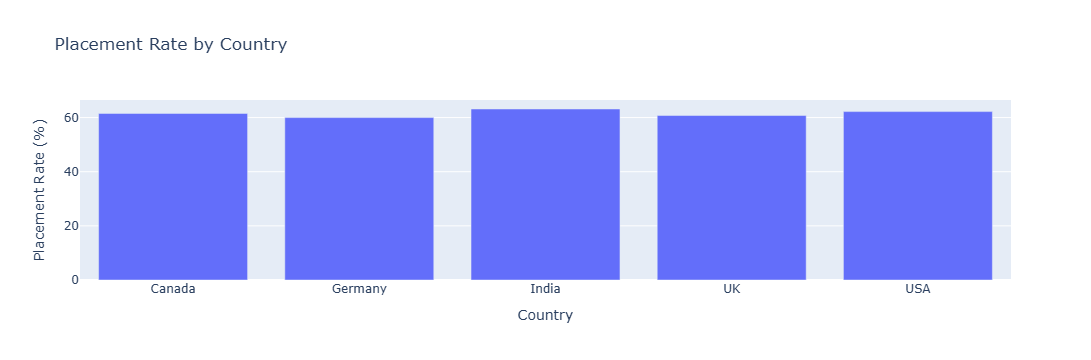

In [79]:
fig = px.bar(
    x=placement_rate.index,
    y=placement_rate.values,
    labels={'x': 'Country', 'y': 'Placement Rate (%)'},
    title="Placement Rate by Country"
)

fig.show()

In [80]:
# Which country offers the highest average salary? 
df.groupby('country')['salary'].mean().round(2)

country
Canada     59272.71
Germany    56136.94
India      32005.00
UK         60693.50
USA        68837.34
Name: salary, dtype: float64

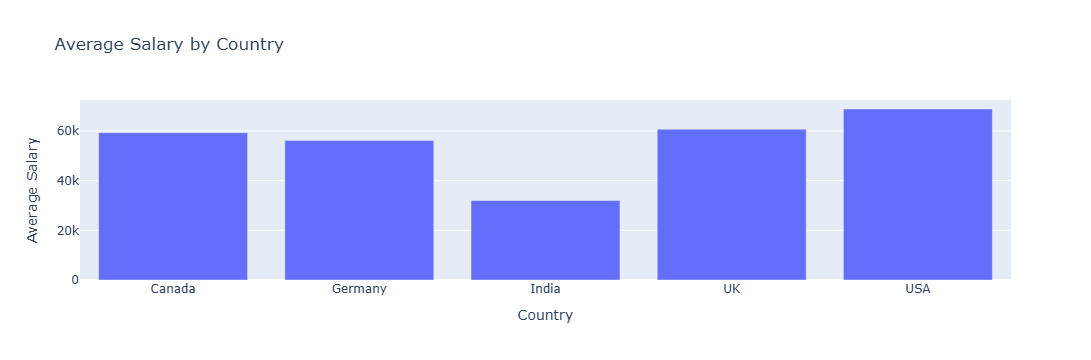

In [81]:
avg_salary = df.groupby('country')['salary'].mean().round(2).reset_index()

fig = px.bar(
    avg_salary,
    x='country',
    y='salary',
    title="Average Salary by Country",
    labels={'country': 'Country', 'salary': 'Average Salary'}
)

fig.show()

In [82]:
# How does placement vary across different countries?
df.groupby('country')['placement_status'].value_counts()

country  placement_status
Canada   Placed              1216
         Not Placed           760
Germany  Placed              1234
         Not Placed           823
India    Placed              1254
         Not Placed           731
UK       Placed              1180
         Not Placed           762
USA      Placed              1269
         Not Placed           771
Name: count, dtype: int64

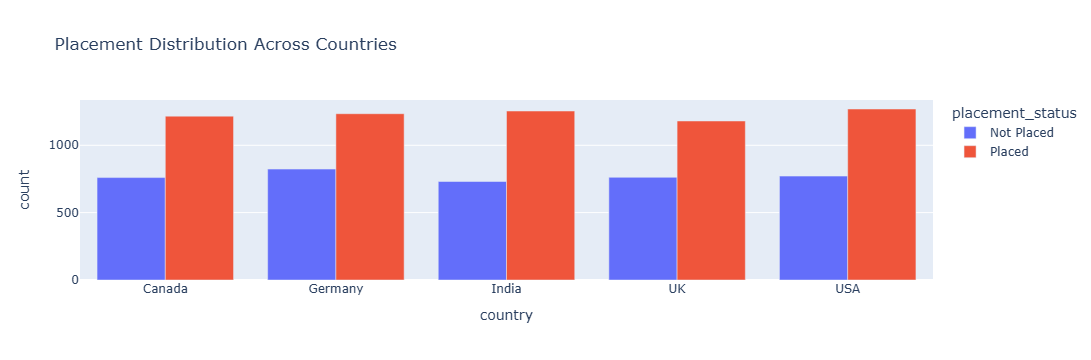

In [83]:
placement_country = df.groupby(['country','placement_status']).size().reset_index(name='count')

fig = px.bar(
    placement_country,
    x='country',
    y='count',
    color='placement_status',
    barmode='group',
    title="Placement Distribution Across Countries"
)

fig.show()

# Internship Analysis


In [84]:
# What is the average internship count among students?
df['internship_count'].mean()

np.float64(1.4993)

In [85]:
# Do students with more internships get placed more often?
df.groupby('internship_count')['placement_status'].value_counts(normalize=True) * 100

internship_count  placement_status
0                 Not Placed          50.883552
                  Placed              49.116448
1                 Placed              57.181329
                  Not Placed          42.818671
2                 Placed              66.313310
                  Not Placed          33.686690
3                 Placed              74.476651
                  Not Placed          25.523349
4                 Placed              81.002088
                  Not Placed          18.997912
5                 Placed              85.245902
                  Not Placed          14.754098
Name: proportion, dtype: float64

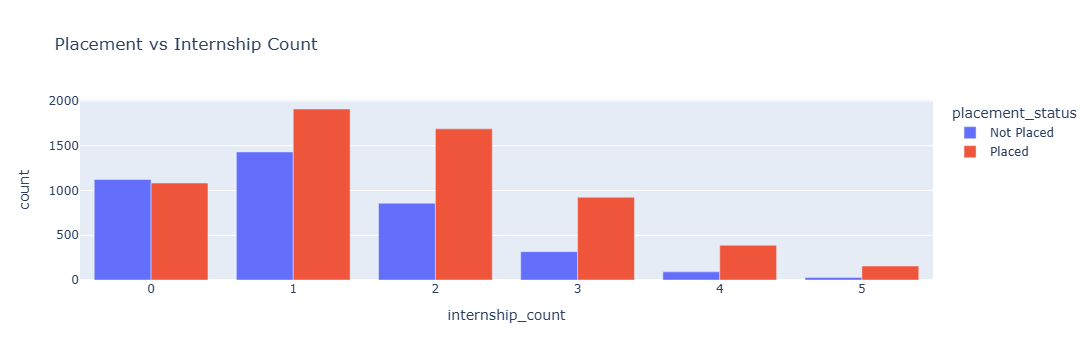

In [86]:
internship_placement = (
    df.groupby(['internship_count','placement_status'])
    .size()
    .reset_index(name='count')
)

fig = px.bar(
    internship_placement,
    x='internship_count',
    y='count',
    color='placement_status',
    barmode='group',
    title='Placement vs Internship Count'
)

fig.show()

In [87]:
# What is the relationship between internship quality score and salary?
df[['internship_quality_score', 'salary']].corr()

,internship_quality_score,salary
internship_quality_score,1.000000,0.196747
salary,0.196747,1.000000


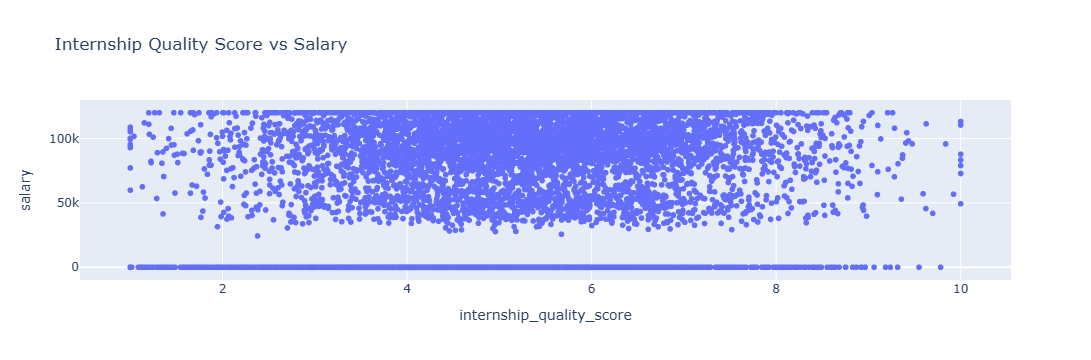

In [88]:
fig = px.scatter(
    df,
    x='internship_quality_score',
    y='salary',
    title='Internship Quality Score vs Salary'
)

fig.show()

# Skill Score Analysis

In [89]:
# What is the average aptitude score of studets? 
df['aptitude_score'].mean().round(2)

np.float64(69.88)

In [90]:
# Do students with higher aptitude scores get higher salaries?
df[['aptitude_score','salary']].corr()

,aptitude_score,salary
aptitude_score,1.00000,0.07547
salary,0.07547,1.00000


In [91]:
# What is the relationship between communication score and placement? 
df.groupby('placement_status')['communication_score'].mean().round(2)

placement_status
Not Placed    63.36
Placed        66.28
Name: communication_score, dtype: float64

In [92]:
'''Which score has stronger impact on placement:
aptitude_score
communication_score'''

df.groupby('placement_status')[['aptitude_score','communication_score']].mean().round(2)

,aptitude_score,communication_score
placement_status,,
Not Placed,68.20,63.36
Placed,70.93,66.28


# Specialization Analysis

In [93]:
# Which specialization has the most students? 
df['specialization'].value_counts()

specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64

In [94]:
# Which specialization has the highest placement rate?
df.groupby('specialization')['placement_status'].value_counts(normalize=True) * 100

specialization  placement_status
AI/ML           Placed              61.577097
                Not Placed          38.422903
Cloud           Placed              63.728470
                Not Placed          36.271530
Core CS         Placed              59.691081
                Not Placed          40.308919
Cybersecurity   Placed              61.947791
                Not Placed          38.052209
Data Science    Placed              60.756385
                Not Placed          39.243615
Name: proportion, dtype: float64

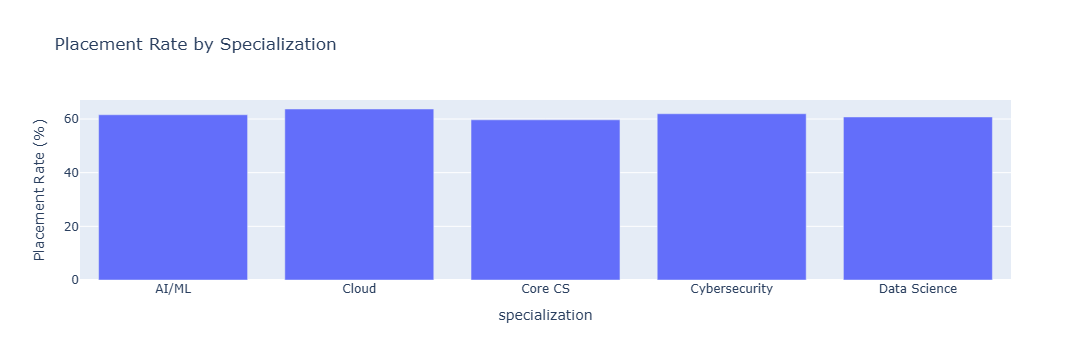

In [95]:
placement_rate = (
    df.groupby('specialization')['placement_status']
    .value_counts(normalize=True)
    .unstack()['Placed'] * 100
).reset_index()

fig = px.bar(
    placement_rate,
    x='specialization',
    y='Placed',
    title='Placement Rate by Specialization',
    labels={'Placed':'Placement Rate (%)'}
)

fig.show()

In [96]:
# Which specialization receives the highest salary on average?
df.groupby('specialization')['salary'].mean().round()

specialization
AI/ML            58774.0
Cloud            55434.0
Core CS          51283.0
Cybersecurity    53763.0
Data Science     57935.0
Name: salary, dtype: float64

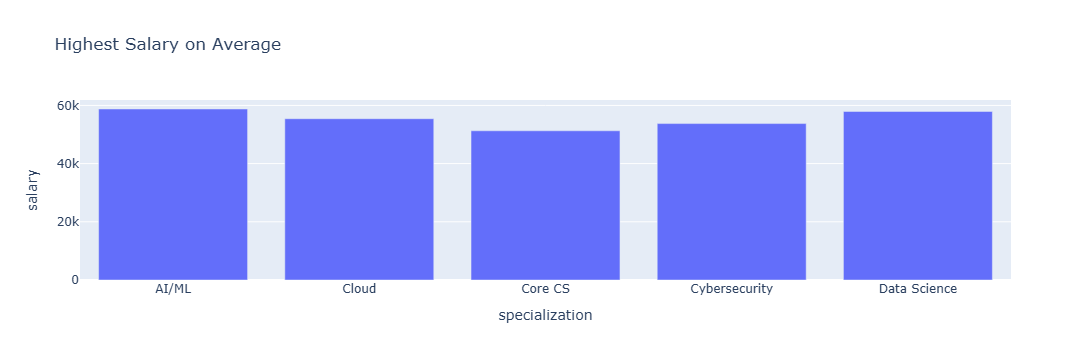

In [97]:
highest_salary = (df.groupby('specialization')['salary'].mean().round()).reset_index()
fig = px.bar(
    highest_salary,
    x='specialization',
    y='salary',
    title = "Highest Salary on Average"
)
fig.show()

# Industry Analysis

In [98]:
# Which industry hires the most graduates? 
df[df['placement_status'] == 'Placed']['industry'].value_counts()

industry
Tech             1107
Consulting       1079
Healthcare       1071
Finance          1051
Manufacturing     929
Other             916
Name: count, dtype: int64

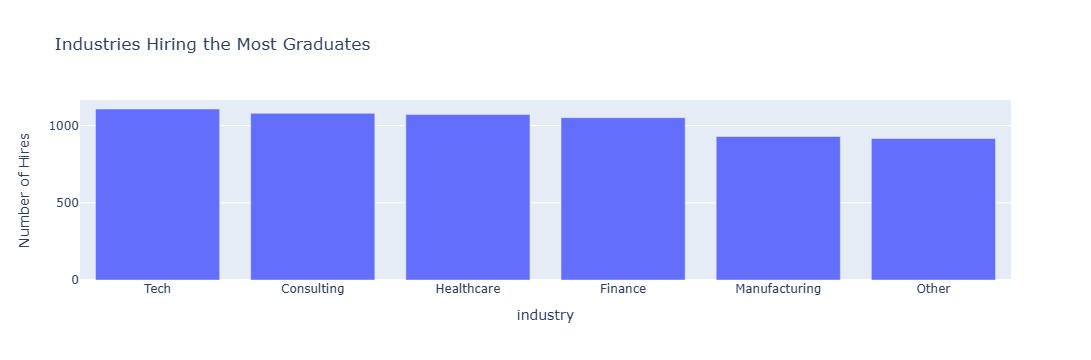

In [99]:
industry_hires = df[df['placement_status'] == 'Placed']['industry'].value_counts().reset_index()

industry_hires.columns = ['industry', 'count']

fig = px.bar(
    industry_hires,
    x='industry',
    y='count',
    title='Industries Hiring the Most Graduates',
    labels={'count':'Number of Hires'}
)

fig.show()

In [100]:
# Which industry pays the highest average salary?
df.groupby('industry')['salary'].mean().sort_values(ascending=False)

industry
Tech             62695.329979
Finance          59487.335481
Healthcare       57001.974339
Consulting       54046.067196
Other            50282.482606
Manufacturing    49277.566956
Name: salary, dtype: float64

In [101]:
# Which specialization is most common in each industry?
df.groupby('industry')['specialization'].value_counts()

industry       specialization
Consulting     Data Science      375
               Cloud             352
               Core CS           346
               Cybersecurity     346
               AI/ML             320
Finance        AI/ML             344
               Data Science      335
               Core CS           326
               Cybersecurity     318
               Cloud             312
Healthcare     Data Science      356
               Cybersecurity     340
               AI/ML             339
               Core CS           328
               Cloud             317
Manufacturing  Core CS           369
               AI/ML             338
               Cloud             337
               Cybersecurity     333
               Data Science      296
Other          Data Science      349
               Core CS           347
               Cloud             321
               Cybersecurity     308
               AI/ML             305
Tech           Cybersecurity     347
        

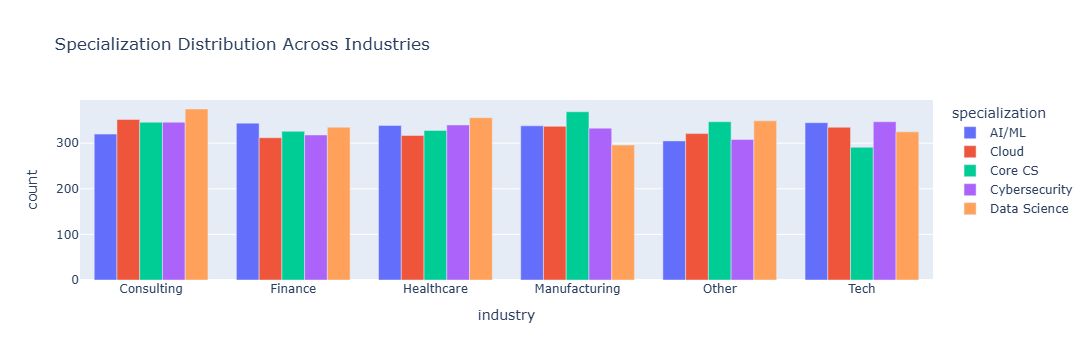

In [102]:
industry_spec = (
    df.groupby(['industry','specialization'])
    .size()
    .reset_index(name='count')
)

fig = px.bar(
    industry_spec,
    x='industry',
    y='count',
    color='specialization',
    barmode='group',
    title='Specialization Distribution Across Industries'
)

fig.show()

# Salary Analysis

In [103]:
# What is the average salary of placed students?
df[df['placement_status'] == 'Placed']['salary'].mean().round(2)

np.float64(90105.88)

In [104]:
# What is the salary distribution?
df['salary'].describe()

count     10000.000000
mean      55442.146458
std       47995.029325
min           0.000000
25%           0.000000
50%       63431.317260
75%      100600.617480
max      120000.000000
Name: salary, dtype: float64

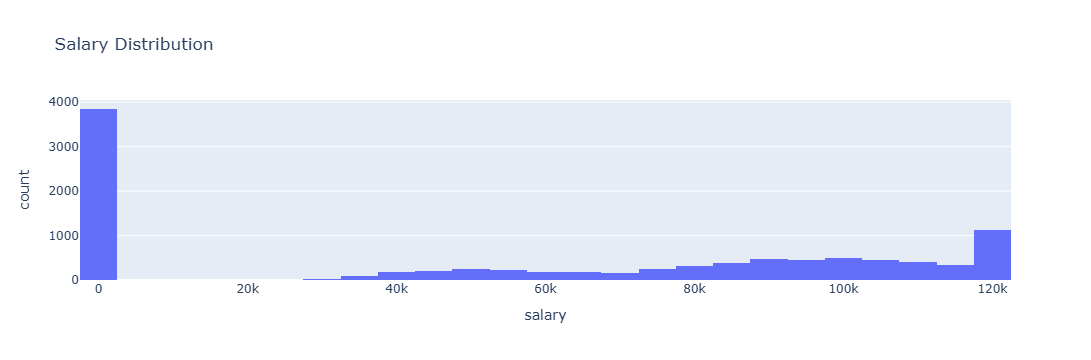

In [105]:
fig = px.histogram(
    df,
    x='salary',
    nbins=30,
    title='Salary Distribution'
)

fig.show()

In [106]:
'''Which factors influence salary the most:

CGPA

Internships

Aptitude score

Communication score'''

df[['cgpa','internship_count','aptitude_score','communication_score','salary']].corr()['salary']

cgpa                   0.334346
internship_count       0.183538
aptitude_score         0.075470
communication_score    0.086082
salary                 1.000000
Name: salary, dtype: float64

In [107]:
# What is the salary difference between college tiers?
df.groupby('college_tier')['salary'].mean().round()

college_tier
Tier 1    64042.0
Tier 2    55720.0
Tier 3    46293.0
Name: salary, dtype: float64

# Correlation Analysis

In [108]:
# Which numeric features have the highest correlation with salary?
df.corr(numeric_only=True)['salary'].sort_values(ascending=False)

salary                      1.000000
cgpa                        0.334346
internship_quality_score    0.196747
internship_count            0.183538
communication_score         0.086082
aptitude_score              0.075470
backlogs                   -0.344342
Name: salary, dtype: float64

In [109]:
# Is there correlation between CGPA and aptitude score? 
df[['cgpa','aptitude_score']].corr()

,cgpa,aptitude_score
cgpa,1.000000,-0.011887
aptitude_score,-0.011887,1.000000


In [110]:
# Does internship quality correlate with salary?
df[['internship_quality_score','salary']].corr()

,internship_quality_score,salary
internship_quality_score,1.000000,0.196747
salary,0.196747,1.000000


In [111]:
# Which variable is the best predictor of placement? 
df['placement_numeric'] = df['placement_status'].map({'Placed':1, 'Not Placed':0})

df.corr(numeric_only=True)['placement_numeric'].sort_values(ascending=False)

placement_numeric           1.000000
salary                      0.913447
cgpa                        0.332766
internship_quality_score    0.214554
internship_count            0.200068
communication_score         0.096355
aptitude_score              0.090370
backlogs                   -0.366188
Name: placement_numeric, dtype: float64

# Visualization Questions

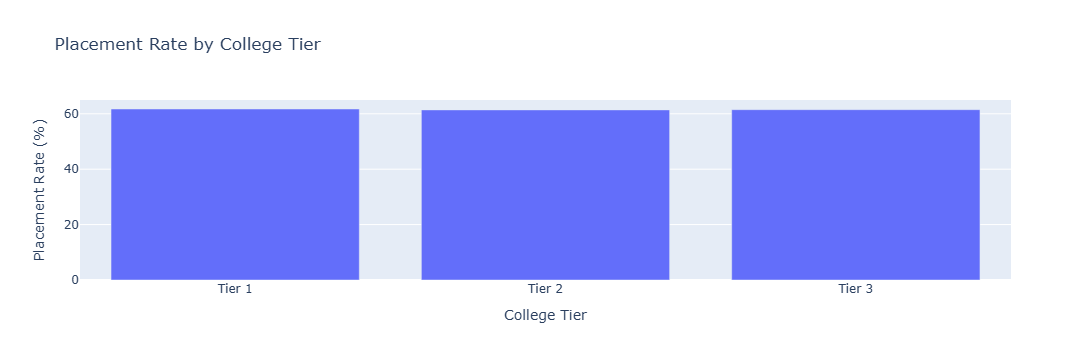

In [112]:
# Create a bar chart of placement rate by college tier. 
placement_rate = (
    df.groupby('college_tier')['placement_status']
    .value_counts(normalize=True)
    .unstack()['Placed'] * 100
).reset_index()

fig = px.bar(
    placement_rate,
    x='college_tier',
    y='Placed',
    title='Placement Rate by College Tier',
    labels={'Placed':'Placement Rate (%)', 'college_tier':'College Tier'}
)

fig.show()

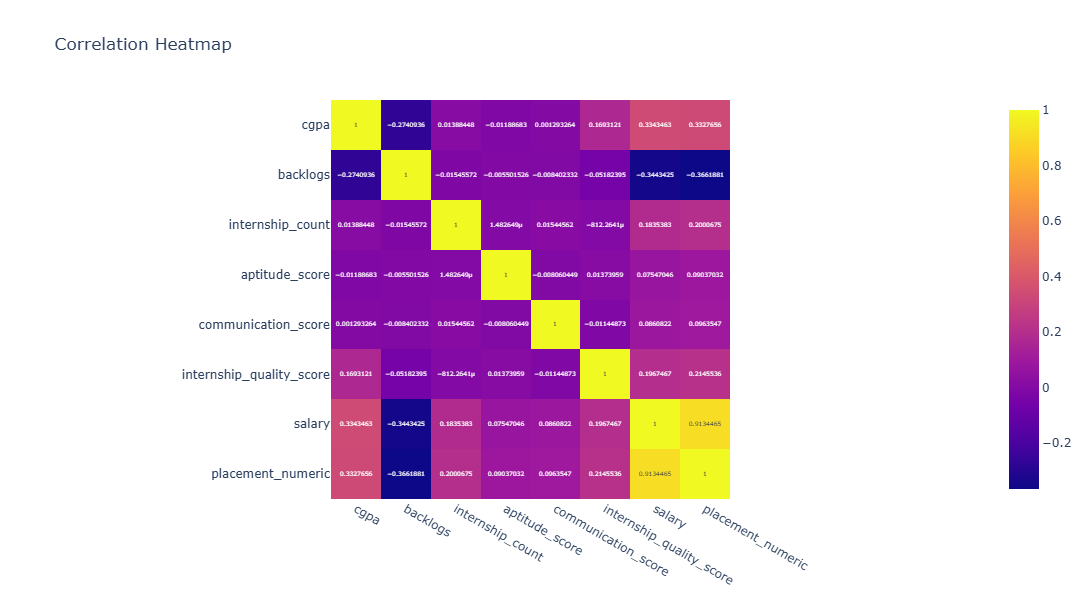

In [114]:
# Create a heatmap for correlations.
corr = df.corr(numeric_only=True)
fig = px.imshow(
    corr,
    text_auto=True,
    title="Correlation Heatmap",
    width=800,
    height=600
)

fig.show()

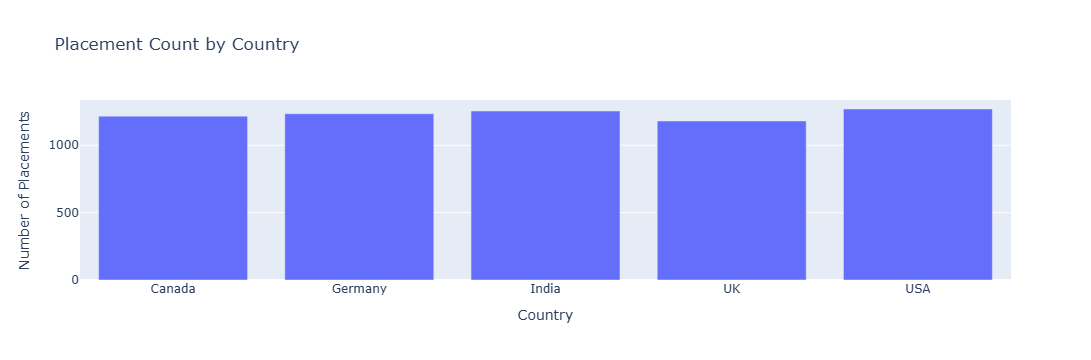

In [115]:
# Show placement count by country.
placement_country = df[df['placement_status'] == 'Placed'].groupby('country').size().reset_index(name='count')

fig = px.bar(
    placement_country,
    x='country',
    y='count',
    title='Placement Count by Country',
    labels={'count':'Number of Placements', 'country':'Country'}
)

fig.show()

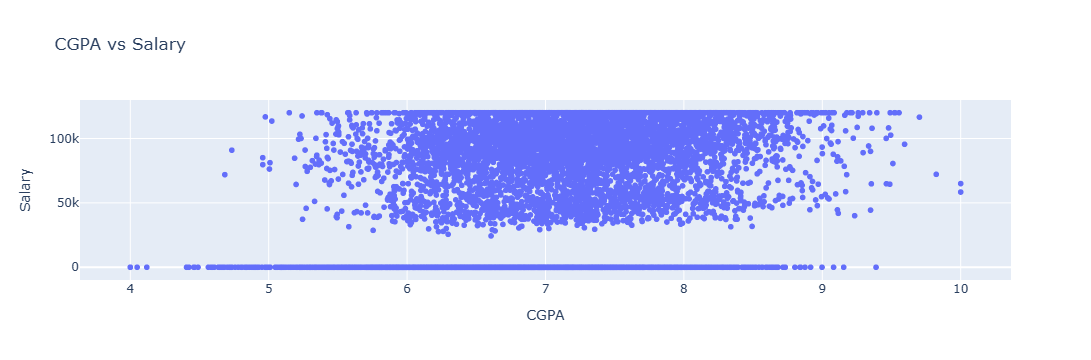

In [116]:
# Plot CGPA vs Salary scatter plot.
fig = px.scatter(
    df,
    x='cgpa',
    y='salary',
    title='CGPA vs Salary',
    labels={'cgpa':'CGPA', 'salary':'Salary'}
)

fig.show()

!python dashboard.py

http://127.0.0.1:8050